# Tilt and vertical velocity for individual eddy days

This notebook compares measured `TiltDis` and `TiltDir` with model vertical velocity for individual eddy-days. It reads the saved per-depth velocity cache from notebook 02 and the existing tilt table; it does not read model NetCDF files. The footprint is fixed at core fraction 1.5 and depths are limited to 0–1,000 m. Positive model `w` means upward motion. `TiltDir` is retained in the dataset's original deep-to-shallow bearing convention, including its configured offset.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

HERE=Path.cwd()
if HERE.name!='vertical_velocity': raise RuntimeError('Launch from the vertical_velocity folder')
sys.path.insert(0,str(HERE.parent))
import seacofs_tilt_tools as tilt
from vertical_velocity_tools import column_extrema


In [2]:
FRACTION=1.5
MAX_DEPTH_M=1000
MIN_CORE_CELLS=8
MIN_COVERAGE=0.7
N_PROFILE_DAYS_PER_CLASS=3
PROFILE_CASES=None  # Optionally set [(eddy_id, day), ...] to inspect specific days.
SEED=731
CACHE_PATH=Path('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset_modular/vertical_velocity_climatology/core_vertical_velocity_upper_1000m.parquet')


In [3]:
raw=pd.read_parquet(CACHE_PATH)
required={'Eddy','Day','fraction','Depth','n_valid','coverage','w_mean','w_rms','w_max','w_min','z_max_m','z_min_m'}
missing=required-set(raw.columns)
if missing: raise ValueError(f'Cache is missing {sorted(missing)}; rerun notebook 02')
depth=raw.loc[np.isclose(raw.fraction,FRACTION)&raw.Depth.between(0,MAX_DEPTH_M)].copy()
depth=depth.loc[depth.n_valid.ge(MIN_CORE_CELLS)&depth.coverage.ge(MIN_COVERAGE)]
depth=depth.dropna(subset=['w_mean','w_max','w_min'])
if depth.empty: raise ValueError('No cached rows remain after fraction/depth/coverage filters')
if depth.duplicated(['Eddy','Day','Depth']).any(): raise ValueError('Duplicate eddy-day-depth rows')
depth['abs_max_w']=depth[['w_max','w_min']].abs().max(axis=1)

surface,_=tilt.load_tilt_tables()
identity=surface[['Eddy','Day','Cyc','TiltDis','TiltDir']].drop_duplicates(['Eddy','Day'])
if identity.duplicated(['Eddy','Day']).any(): raise ValueError('Duplicate keys in tilt table')
depth=depth.drop(columns=['Cyc','TiltDis','TiltDir'],errors='ignore').merge(identity,on=['Eddy','Day'],how='left',validate='many_to_one')
depth=depth.loc[depth.Cyc.isin(['AE','CE'])].dropna(subset=['TiltDis','TiltDir'])
print('Retained observations:')
display(depth.groupby('Cyc').agg(depth_rows=('Depth','size'),eddies=('Eddy','nunique'),median_coverage=('coverage','median')))


Retained observations:


,depth_rows,eddies,median_coverage
Cyc,,,
AE,6904,142,1.0
CE,7850,148,1.0


## One row per eddy day

`w_mean` is the mean of all valid sampled core cells across fitted depths, weighted by the number of cells at each depth. It is a sample mean, not a volume flux. `abs_max_w` is the largest absolute sampled cell velocity in the column; `w_max` and `w_min` retain the separate upward and downward extremes. Single-cell extremes can depend on noise and footprint size.


In [4]:
snapshot=column_extrema(depth)
identity=depth[['Eddy','Day','Cyc','TiltDis','TiltDir']].drop_duplicates(['Eddy','Day'])
snapshot=snapshot.merge(identity,on=['Eddy','Day'],how='left',validate='one_to_one')
snapshot['abs_max_w']=snapshot.w_abs_max.abs()
snapshot=snapshot.sort_values(['Cyc','Eddy','Day']).reset_index(drop=True)
print('Eddy-day counts:')
display(snapshot.groupby('Cyc').agg(eddy_days=('Day','size'),eddies=('Eddy','nunique')))
display(snapshot[['Eddy','Day','Cyc','TiltDis','TiltDir','w_mean','abs_max_w','w_max','w_min','n_depths','min_coverage']].head(12))


Eddy-day counts:


,eddy_days,eddies
Cyc,,
AE,336,142
CE,375,148


,Eddy,Day,Cyc,TiltDis,TiltDir,w_mean,abs_max_w,w_max,w_min,n_depths,min_coverage
0,27,1509,AE,19.671999,212.972500,4.296670e-06,0.000432,0.000432,-0.000130,22,1.000000
1,27,1519,AE,13.060148,210.404003,4.510616e-07,0.000133,0.000105,-0.000133,22,1.000000
2,40,1572,AE,17.711905,131.770152,7.132149e-06,0.003957,0.003957,-0.001577,22,0.933475
3,40,1580,AE,22.318018,18.283264,-2.275526e-06,0.002725,0.002725,-0.001526,22,0.947954
4,45,1588,AE,29.927877,299.500897,1.648408e-06,0.000903,0.000531,-0.000903,12,1.000000
5,61,1650,AE,103.948130,293.163102,-6.404010e-06,0.002723,0.001435,-0.002723,21,0.888793
6,73,1699,AE,35.551519,350.602128,-6.371393e-06,0.000467,0.000429,-0.000467,22,0.721560
7,73,1718,AE,15.179071,23.918634,-1.720561e-05,0.000822,0.000794,-0.000822,22,0.746976
8,73,1722,AE,10.687773,113.035893,6.245243e-06,0.000743,0.000743,-0.000455,22,0.750510
9,92,1715,AE,6.218993,177.447468,-1.074005e-05,0.000397,0.000363,-0.000397,17,1.000000


## Individual vertical profiles

Choose `PROFILE_CASES` above to inspect particular eddy-days, or use the reproducible AE/CE sample below. Each panel shows the core mean and the largest upward and downward velocities at each fitted depth. The column-wide mean and absolute maximum appear in the title.


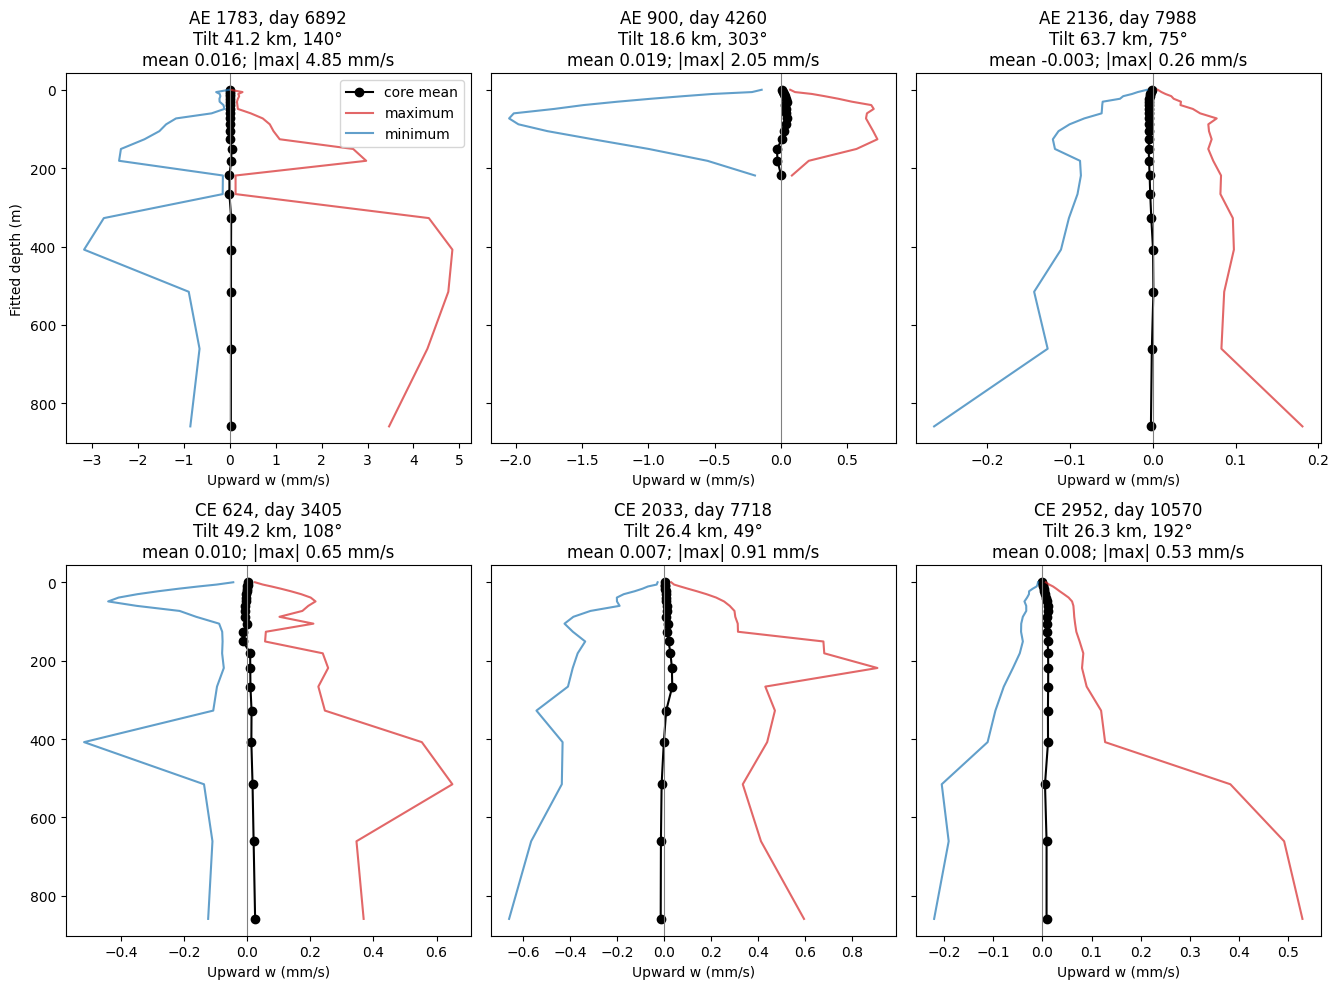

In [5]:
if PROFILE_CASES is None:
    cases=[]
    for cyc in ('AE','CE'):
        rows=snapshot.loc[snapshot.Cyc.eq(cyc)]
        chosen=rows.sample(n=min(N_PROFILE_DAYS_PER_CLASS,len(rows)),random_state=SEED)
        cases += list(chosen[['Eddy','Day']].itertuples(index=False,name=None))
else:
    cases=list(PROFILE_CASES)
if not cases: raise ValueError('No eddy-days available for profile plots')
ncols=min(3,len(cases));nrows=int(np.ceil(len(cases)/ncols))
fig,axes=plt.subplots(nrows,ncols,figsize=(4.5*ncols,5*nrows),sharey=True,squeeze=False)
for ax,(eddy_id,day) in zip(axes.flat,cases):
    d=depth.loc[depth.Eddy.eq(eddy_id)&depth.Day.eq(day)].sort_values('Depth')
    s=snapshot.loc[snapshot.Eddy.eq(eddy_id)&snapshot.Day.eq(day)]
    if d.empty or len(s)!=1: raise ValueError(f'Cached eddy-day {(eddy_id,day)} not found')
    s=s.iloc[0]
    ax.plot(1e3*d.w_mean,d.Depth,'o-',color='black',label='core mean')
    ax.plot(1e3*d.w_max,d.Depth,'-',color='tab:red',alpha=.7,label='maximum')
    ax.plot(1e3*d.w_min,d.Depth,'-',color='tab:blue',alpha=.7,label='minimum')
    ax.axvline(0,color='.5',lw=.8)
    ax.set(title=f'{s.Cyc} {eddy_id}, day {day}\nTilt {s.TiltDis:.1f} km, {s.TiltDir:.0f}°\nmean {1e3*s.w_mean:.3f}; |max| {1e3*s.abs_max_w:.2f} mm/s',xlabel='Upward w (mm/s)')
for ax in list(axes.flat)[len(cases):]:ax.set_visible(False)
axes[0,0].set_ylabel('Fitted depth (m)');axes[0,0].invert_yaxis();axes[0,0].legend()
fig.tight_layout();plt.show()


## Tilt magnitude versus column vertical velocity

Every point is an eddy-day. Colours distinguish AE and CE. The small table gives descriptive Spearman correlations; days from one eddy are related, so these coefficients and plots are exploratory rather than independent-sample significance tests.


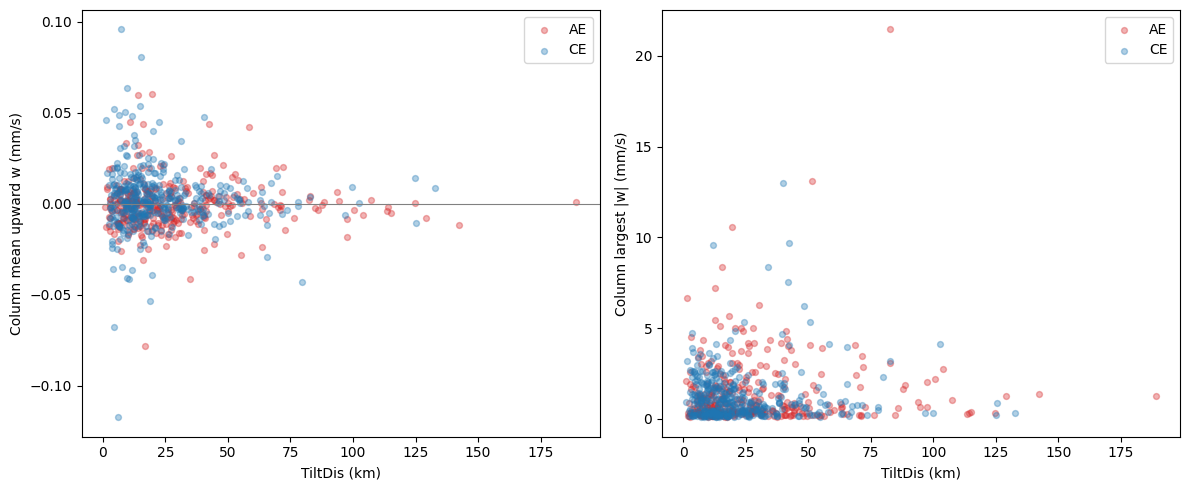

,Cyc,metric,eddy_days,spearman_rho
0,AE,w_mean,336,0.042896
1,AE,abs_max_w,336,0.043857
2,AE,w_max,336,0.007848
3,AE,w_min,336,-0.025539
4,CE,w_mean,375,-0.034035
5,CE,abs_max_w,375,-0.079386
6,CE,w_max,375,-0.041853
7,CE,w_min,375,0.111008


In [6]:
fig,axes=plt.subplots(1,2,figsize=(12,5))
for cyc,color in [('AE','tab:red'),('CE','tab:blue')]:
    d=snapshot.loc[snapshot.Cyc.eq(cyc)]
    axes[0].scatter(d.TiltDis,1e3*d.w_mean,s=18,alpha=.35,color=color,label=cyc)
    axes[1].scatter(d.TiltDis,1e3*d.abs_max_w,s=18,alpha=.35,color=color,label=cyc)
axes[0].axhline(0,color='.5',lw=.8)
axes[0].set(xlabel='TiltDis (km)',ylabel='Column mean upward w (mm/s)')
axes[1].set(xlabel='TiltDis (km)',ylabel='Column largest |w| (mm/s)')
for ax in axes: ax.legend()
fig.tight_layout();plt.show()
rows=[]
for cyc,d in snapshot.groupby('Cyc'):
    for metric in ('w_mean','abs_max_w','w_max','w_min'):
        pair=d[['TiltDis',metric]].dropna()
        rows.append(dict(Cyc=cyc,metric=metric,eddy_days=len(pair),
                         spearman_rho=spearmanr(pair.TiltDis,pair[metric]).statistic))
display(pd.DataFrame(rows))


<Axes: xlabel='w_mean'>

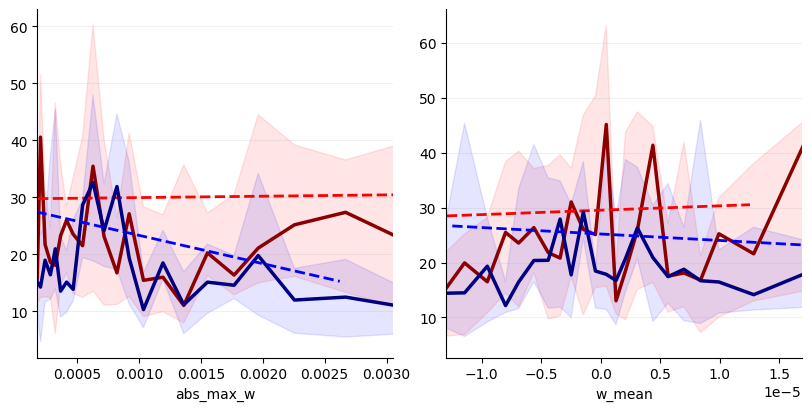

In [7]:
fig, axs = plt.subplots(1,2, figsize=(8,4), constrained_layout=True)
tilt.binned_tilt_panel(axs[0], snapshot, 'abs_max_w', 'abs_max_w', xlim=None, linfit=True)
tilt.binned_tilt_panel(axs[1], snapshot, 'w_mean', 'w_mean', xlim=None, linfit=True)


## Tilt direction versus column vertical velocity

`TiltDir` wraps at 360°. These plots use the dataset bearing as stored and avoid a linear correlation on angles. They show whether days with stronger upward or downward mean motion, or stronger absolute extremes, occupy particular direction sectors. Interpret any pattern together with AE/CE and the number of days per sector.


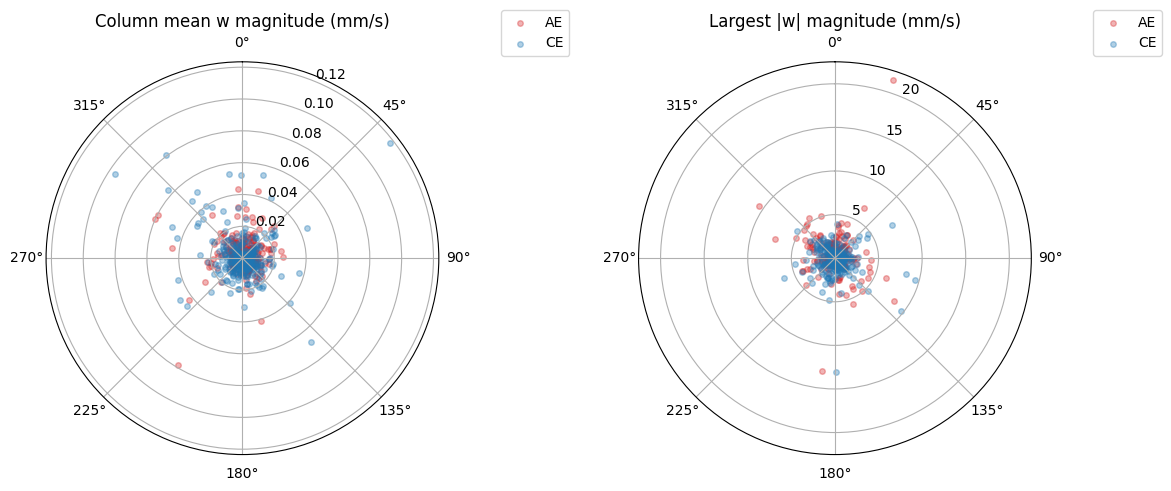

,Cyc,direction_sector,eddy_days,median_tilt_km,median_signed_mean_w,median_abs_max_w
0,AE,"[0, 45)",62,20.420248,-5.868383e-07,0.000877
1,AE,"[45, 90)",47,28.693675,-3.924521e-06,0.000407
2,AE,"[90, 135)",44,22.708695,-2.833042e-06,0.000575
3,AE,"[135, 180)",28,17.564168,3.383095e-06,0.000973
4,AE,"[180, 225)",19,17.025465,4.510616e-07,0.000898
5,AE,"[225, 270)",37,18.101158,-1.203486e-06,0.000802
6,AE,"[270, 315)",40,21.834073,-1.372392e-06,0.000785
7,AE,"[315, 360)",59,21.854704,1.616791e-06,0.000880
8,CE,"[0, 45)",28,17.699595,1.065980e-06,0.000647
9,CE,"[45, 90)",52,17.623929,8.268269e-07,0.000731


In [8]:
fig,axes=plt.subplots(1,2,figsize=(12,5),subplot_kw={'projection':'polar'})
for ax,(metric,label) in zip(axes,[('w_mean','Column mean w'),('abs_max_w','Largest |w|')]):
    for cyc,color in [('AE','tab:red'),('CE','tab:blue')]:
        d=snapshot.loc[snapshot.Cyc.eq(cyc)]
        radius=1e3*d[metric].abs() if metric=='w_mean' else 1e3*d[metric]
        ax.scatter(np.deg2rad(d.TiltDir),radius,s=16,alpha=.35,color=color,label=cyc)
    ax.set_theta_zero_location('N');ax.set_theta_direction(-1)
    ax.set(title=f'{label} magnitude (mm/s)')
    ax.legend(loc='upper right',bbox_to_anchor=(1.35,1.15))
fig.tight_layout();plt.show()

sectors=snapshot.copy()
sectors['direction_sector']=pd.cut(sectors.TiltDir%360,np.arange(0,361,45),right=False,include_lowest=True)
sector_summary=sectors.groupby(['Cyc','direction_sector'],observed=True).agg(
    eddy_days=('Day','size'),median_tilt_km=('TiltDis','median'),
    median_signed_mean_w=('w_mean','median'),median_abs_max_w=('abs_max_w','median')).reset_index()
display(sector_summary)


## Reading the plots

Look first at the individual profiles: a small signed column mean can coexist with large upward and downward cells. Then compare `TiltDis` with both `w_mean` and `abs_max_w` separately for AE and CE. Direction sectors with few eddy-days are descriptive only. This notebook deliberately stops at individual eddy-days; a later population analysis can account for repeated days within eddies if these views reveal a clear pattern.
